In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/graph-response/Meena-Human-Only-Emotion.xlsx
/kaggle/input/graph-response/calculated_dataset.xlsx
/kaggle/input/graph-response/Meena-Human-Only-Sentiment.xlsx


In [2]:
import pandas as pd

# Load Excel file
file_path = "/kaggle/input/graph-response/Meena-Human-Only-Sentiment.xlsx"
df = pd.read_excel(file_path)

# Load Excel sheets (each from different files or same file with different sheet names)
df1 = pd.read_excel("/kaggle/input/graph-response/Meena-Human-Only-Sentiment.xlsx", sheet_name="M3")  # update path and sheet_name if needed
df2 = pd.read_excel("/kaggle/input/graph-response/Meena-Human-Only-Sentiment.xlsx", sheet_name="Oporajita")  # update path and sheet_name if needed

# Combine them vertically
combined_df = pd.concat([df1, df2], ignore_index=True)

# Preview
print(combined_df.head())
combined_df.to_excel("combined_output.xlsx", index=False)


  Group Participant                                        Description  \
0  CUET         P45  I don't know if he knows, the first person who...   
1  CUET         P45  In every aspect, women are doing great! The pr...   
2  CUET         P45  According to science, women can do more labori...   
3  CUET         P45  Women are also doing great in IT sectors and i...   
4  CUET         P50  Implement awareness programs and training to r...   

                        Tag      Type Category Response  Sentiment_Positive  \
0  Accomplishments of Women    Others      NaN       M3              0.6176   
1  Accomplishments of Women    Others      NaN       M3              0.9830   
2  Accomplishments of Women    Others      NaN       M3              0.9380   
3  Accomplishments of Women    Others      NaN       M3              0.9527   
4          Alleviate Biases  Solution     bias       M3              0.0828   

   Sentiment_Neutral  Sentiment_Negative NLPSentiment HumanSentiment  
0        

In [3]:
combined_df = combined_df[combined_df['HumanSentiment'].apply(lambda x: isinstance(x, str) and x.strip() != '')]
combined_df.reset_index(drop=True, inplace=True)
combined_df.to_excel("cleaned_output.xlsx", index=False)
cleaned_df = combined_df.copy()

In [4]:
cleaned_df

,Group,Participant,Description,Tag,Type,Category,Response,Sentiment_Positive,Sentiment_Neutral,Sentiment_Negative,NLPSentiment,HumanSentiment
0,CUET,P45,"I don't know if he knows, the first person who...",Accomplishments of Women,Others,NaN,M3,0.6176,0.3359,0.0465,Positive,Positive
1,CUET,P45,"In every aspect, women are doing great! The pr...",Accomplishments of Women,Others,NaN,M3,0.9830,0.0138,0.0032,Positive,Positive
2,CUET,P45,"According to science, women can do more labori...",Accomplishments of Women,Others,NaN,M3,0.9380,0.0565,0.0055,Positive,Positive
3,CUET,P45,Women are also doing great in IT sectors and i...,Accomplishments of Women,Others,NaN,M3,0.9527,0.0428,0.0045,Positive,Positive
4,CUET,P50,Implement awareness programs and training to r...,Alleviate Biases,Solution,bias,M3,0.0828,0.8046,0.1127,Neutral,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...
109,SUST,P35,"Though there are several labs for CP, thesis a...",Challenges with Coding (Programming): Getting ...,Challenge,Academic,Oporajita,0.0098,0.2555,0.7347,Negative,Negative
110,SUST,P43,I struggle to face my course teachers and talk...,Lack of Female Mentors and Role Models,Challenge,Underrepresentation,Oporajita,0.0137,0.1806,0.8056,Negative,Negative
111,SUST,P43,"We have safety concerns. Also I can say, there...",Lack of Female Mentors and Role Models,Challenge,Underrepresentation,Oporajita,0.0073,0.1420,0.8507,Negative,Negative
112,SUST,P31,"And last but not least, the stares you get whe...",Underrepresentation of Female creating Challenge,Challenge,Underrepresentation,Oporajita,0.0437,0.5449,0.4114,Neutral,Negative


In [5]:
# Set correct column names for analysis
human_col = 'HumanSentiment'
nlp_col = 'NLPSentiment'

# Create a normalized cross-tab (percentage)
crosstab = pd.crosstab(cleaned_df[human_col], cleaned_df[nlp_col], normalize='index') * 100

# Rename axes
crosstab.index.name = 'Human Sentiment'
crosstab.columns.name = 'NLP Sentiment'

# Reorder rows and columns for clarity
ordered_index = ['Positive', 'Neutral', 'Negative']
ordered_columns = ['Positive', 'Neutral', 'Negative']
crosstab = crosstab.reindex(index=ordered_index, columns=ordered_columns)

# Fill missing values with 0
crosstab = crosstab.fillna(0)

# Round the values for display
crosstab.round(1)


NLP Sentiment,Positive,Neutral,Negative
Human Sentiment,,,
Positive,83.3,16.7,0.0
Neutral,30.4,47.8,21.7
Negative,0.0,25.0,75.0


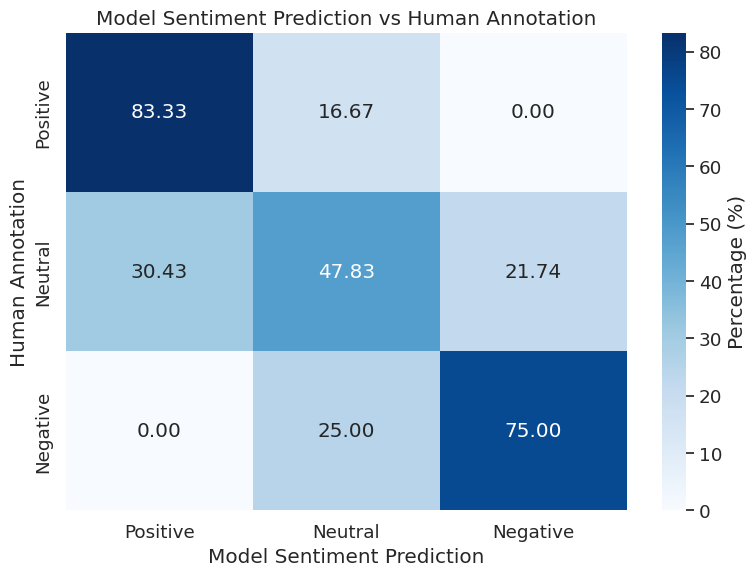

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt



# Optional: set a larger font and figure size

sns.set(font_scale=1.2)
plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, fmt=".2f", cmap="Blues", cbar_kws={'label': 'Percentage (%)'})

plt.title("Model Sentiment Prediction vs Human Annotation")
plt.xlabel("Model Sentiment Prediction")
plt.ylabel("Human Annotation")
plt.tight_layout()
plt.show()


In [7]:
# Set correct column names for analysis
human_col = 'HumanSentiment'
nlp_col = 'NLPSentiment'

# Create a cross-tab with raw counts
crosstab = pd.crosstab(cleaned_df[human_col], cleaned_df[nlp_col])

# Rename axes
crosstab.index.name = 'Human Sentiment'
crosstab.columns.name = 'NLP Sentiment'

# Reorder rows and columns for clarity
ordered_index = ['Positive', 'Neutral', 'Negative']
ordered_columns = ['Positive', 'Neutral', 'Negative']
crosstab = crosstab.reindex(index=ordered_index, columns=ordered_columns)

# Fill missing values with 0
crosstab = crosstab.fillna(0).astype(int)


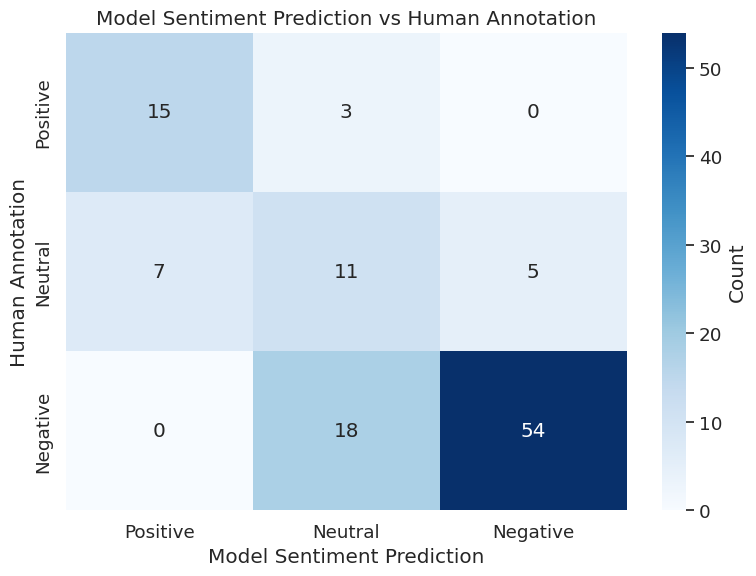

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: set a larger font and figure size
plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, cmap="Blues", cbar_kws={'label': 'Count'})

plt.title("Model Sentiment Prediction vs Human Annotation")
plt.xlabel("Model Sentiment Prediction")
plt.ylabel("Human Annotation")
plt.tight_layout()
plt.show()
